In [71]:
from flonacomldft.utils.io_utils import load_pickle_file, get_project_path
import numpy as np
import matplotlib.pyplot as plt

In [72]:
def load_dic(isomer, ID, i, deep_type):
    if isomer==0:
        name='planar'
    elif isomer==1:
        name='3d'

    dic = load_pickle_file('training/'+name+'/'+str(deep_type)+'s/results/is'+str(isomer)+'_'+str(deep_type)+'_dic_training_'+str(ID)+'_'+str(i)+'.pkl', 
                            path=get_project_path())
    
    return dic

In [73]:
def plot_losses(model_dic, init = 5000, split=100, ax=None):
    
    loss_train, loss_test = model_dic['losses']
    window_train = np.lib.stride_tricks.sliding_window_view(loss_train[init:], split)
    window_test = np.lib.stride_tricks.sliding_window_view(loss_test[init:], split)

    if ax==None:
        fig, ax = plt.subplots(1, 1)
    ax.plot(init+np.arange(len(loss_test[init:])), loss_train[init:], label = 'train')
    ax.plot(init+np.arange(len(loss_test[init:])), loss_test[init:], label = 'test')
    ax.plot(init+np.arange(window_train.mean(-1).shape[0]), window_train.mean(-1), label='average train window {:d}'.format(split))
    ax.plot(init+np.arange(window_test.mean(-1).shape[0]), window_test.mean(-1), label='average test window {:d}'.format(split))
    ax.plot(np.linspace(0, len(loss_train), 10), np.ones(10)*8/9*min(loss_test), 'o', label='models saved')
    #ax.set_yscale('log')
    ax.legend()
    ax.set_ylabel('loss')
    ax.set_xlabel('number iterations')
    ax.set_title('mode label: {:d}, hidden dim: {:d}, hidden depth: {:d}'.format(model_dic['args']['mode_label'], model_dic['args']['hidden_dim'], model_dic['args']['hidden_depth']));
    
    return ax

In [74]:
# ========================= TUNING Flows =========================

In [75]:
n_hdp = 5
ids_flow_0 = 2147988 + np.arange(0, n_hdp)
ids_flow_1 = 2147994 + np.arange(0, n_hdp)

In [76]:
start=4; end=36+1; step=16
list(range(start, end, step))

[4, 20, 36]

In [77]:
flows_0 = [np.array([load_dic(0, id_flow_0, i, 'flow') for i in range(start, end, step)]) for id_flow_0 in ids_flow_0]
flows_1 = [np.array([load_dic(1, id_flow_1, i, 'flow') for i in range(start, end, step)]) for id_flow_1 in ids_flow_1]

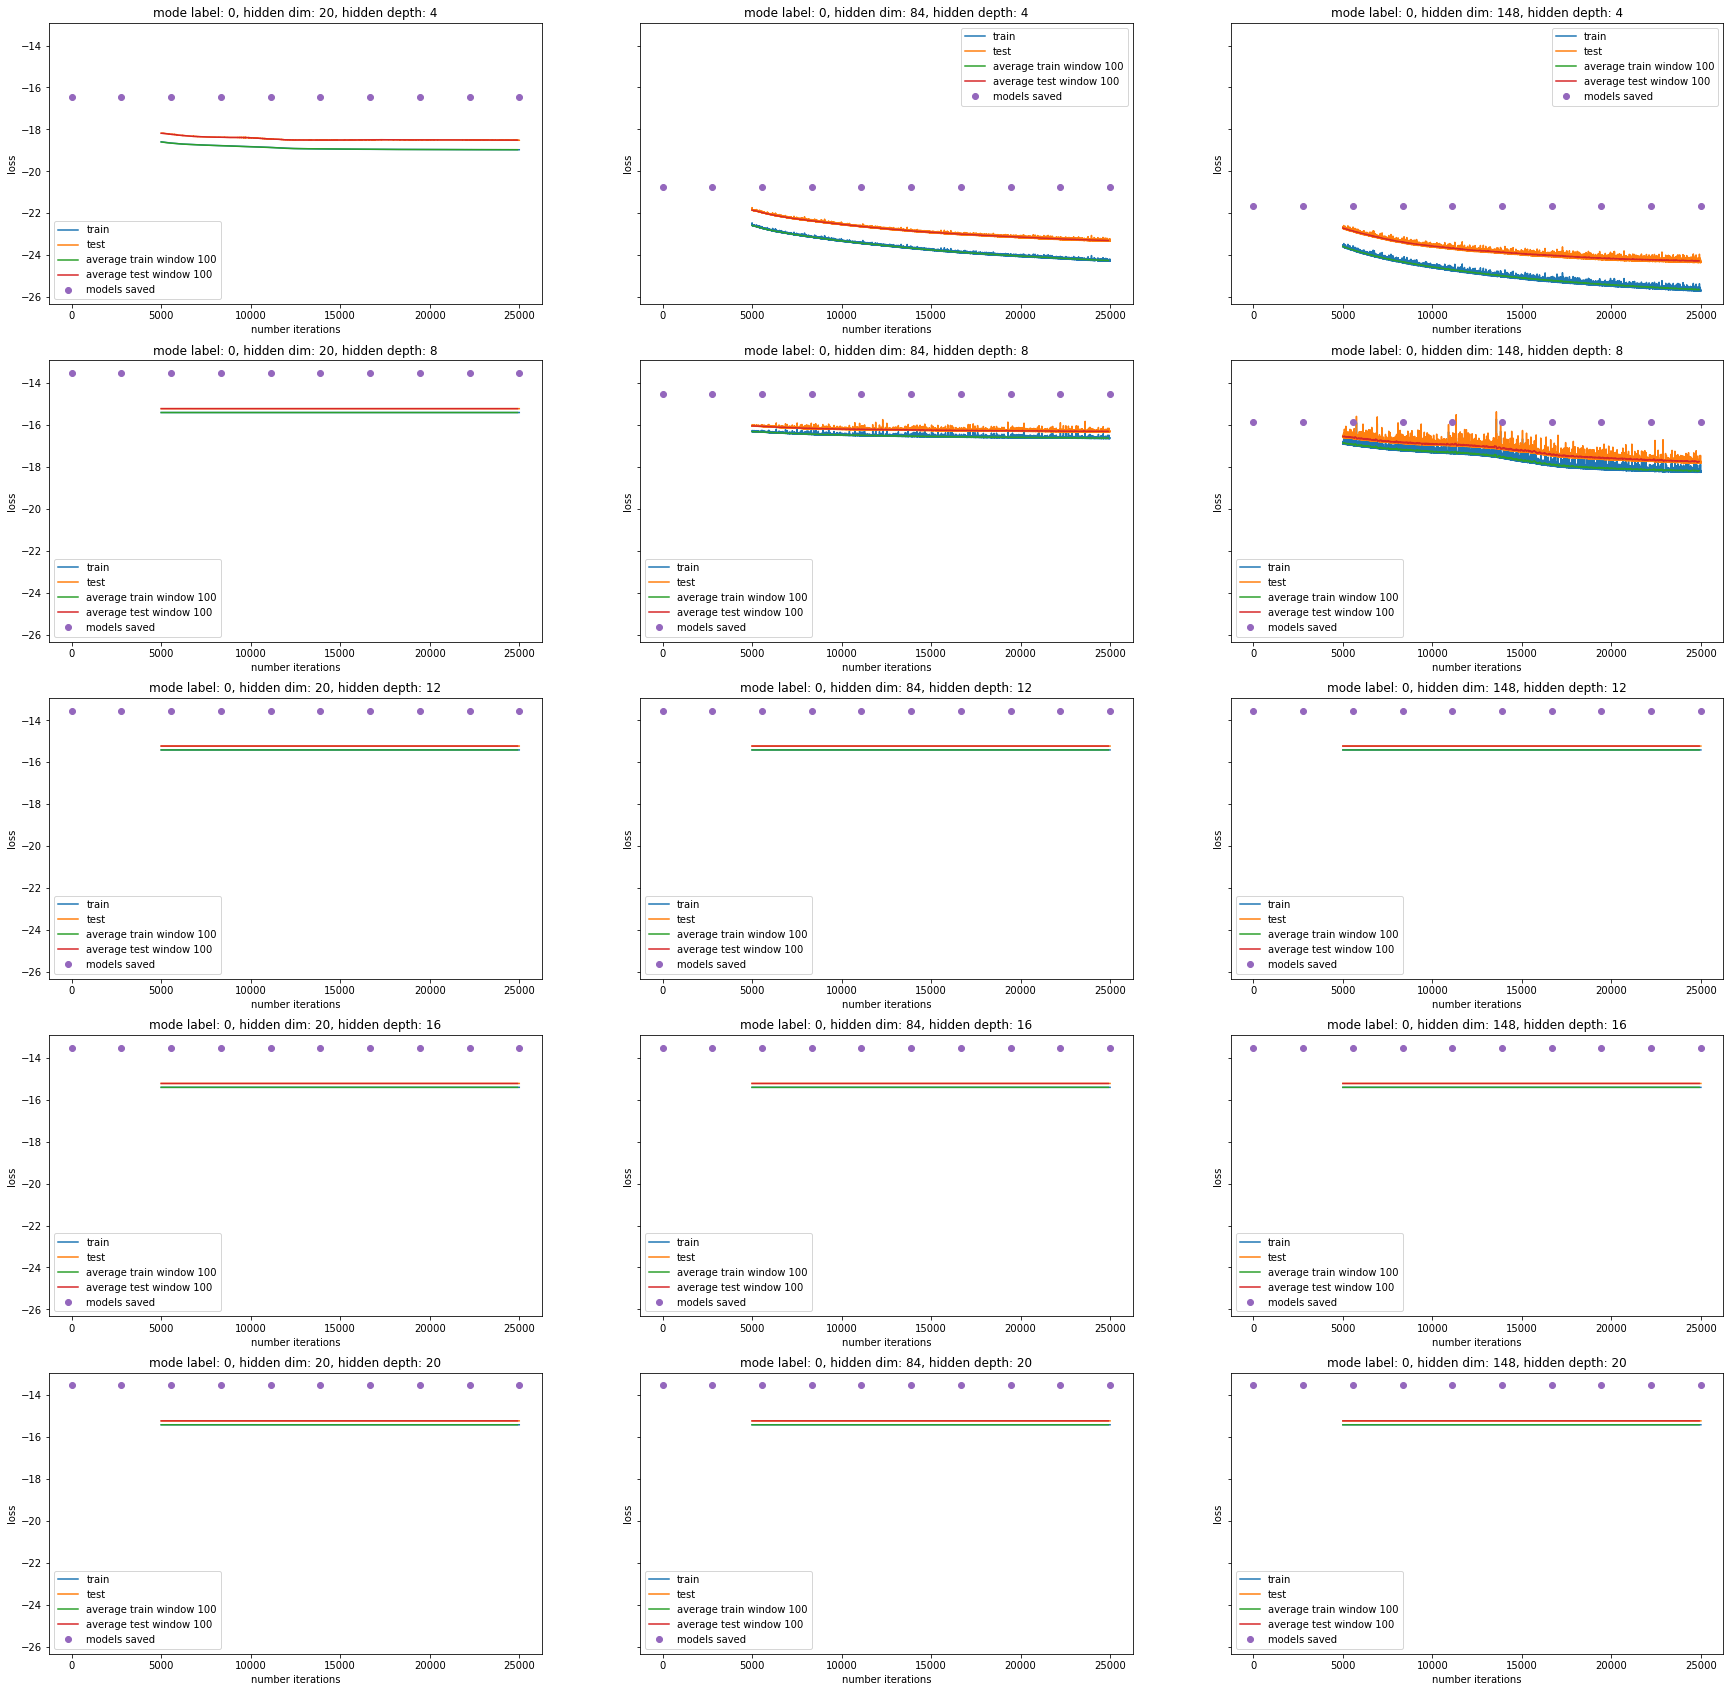

In [78]:
fig, axs = plt.subplots(len(flows_0), len(flows_0[0]), figsize=(30, 30), sharey=True)
for i in range(len(flows_0)):
    for j in range(len(flows_0[i])):
        plot_losses(flows_0[i][j], ax=axs[i][j])

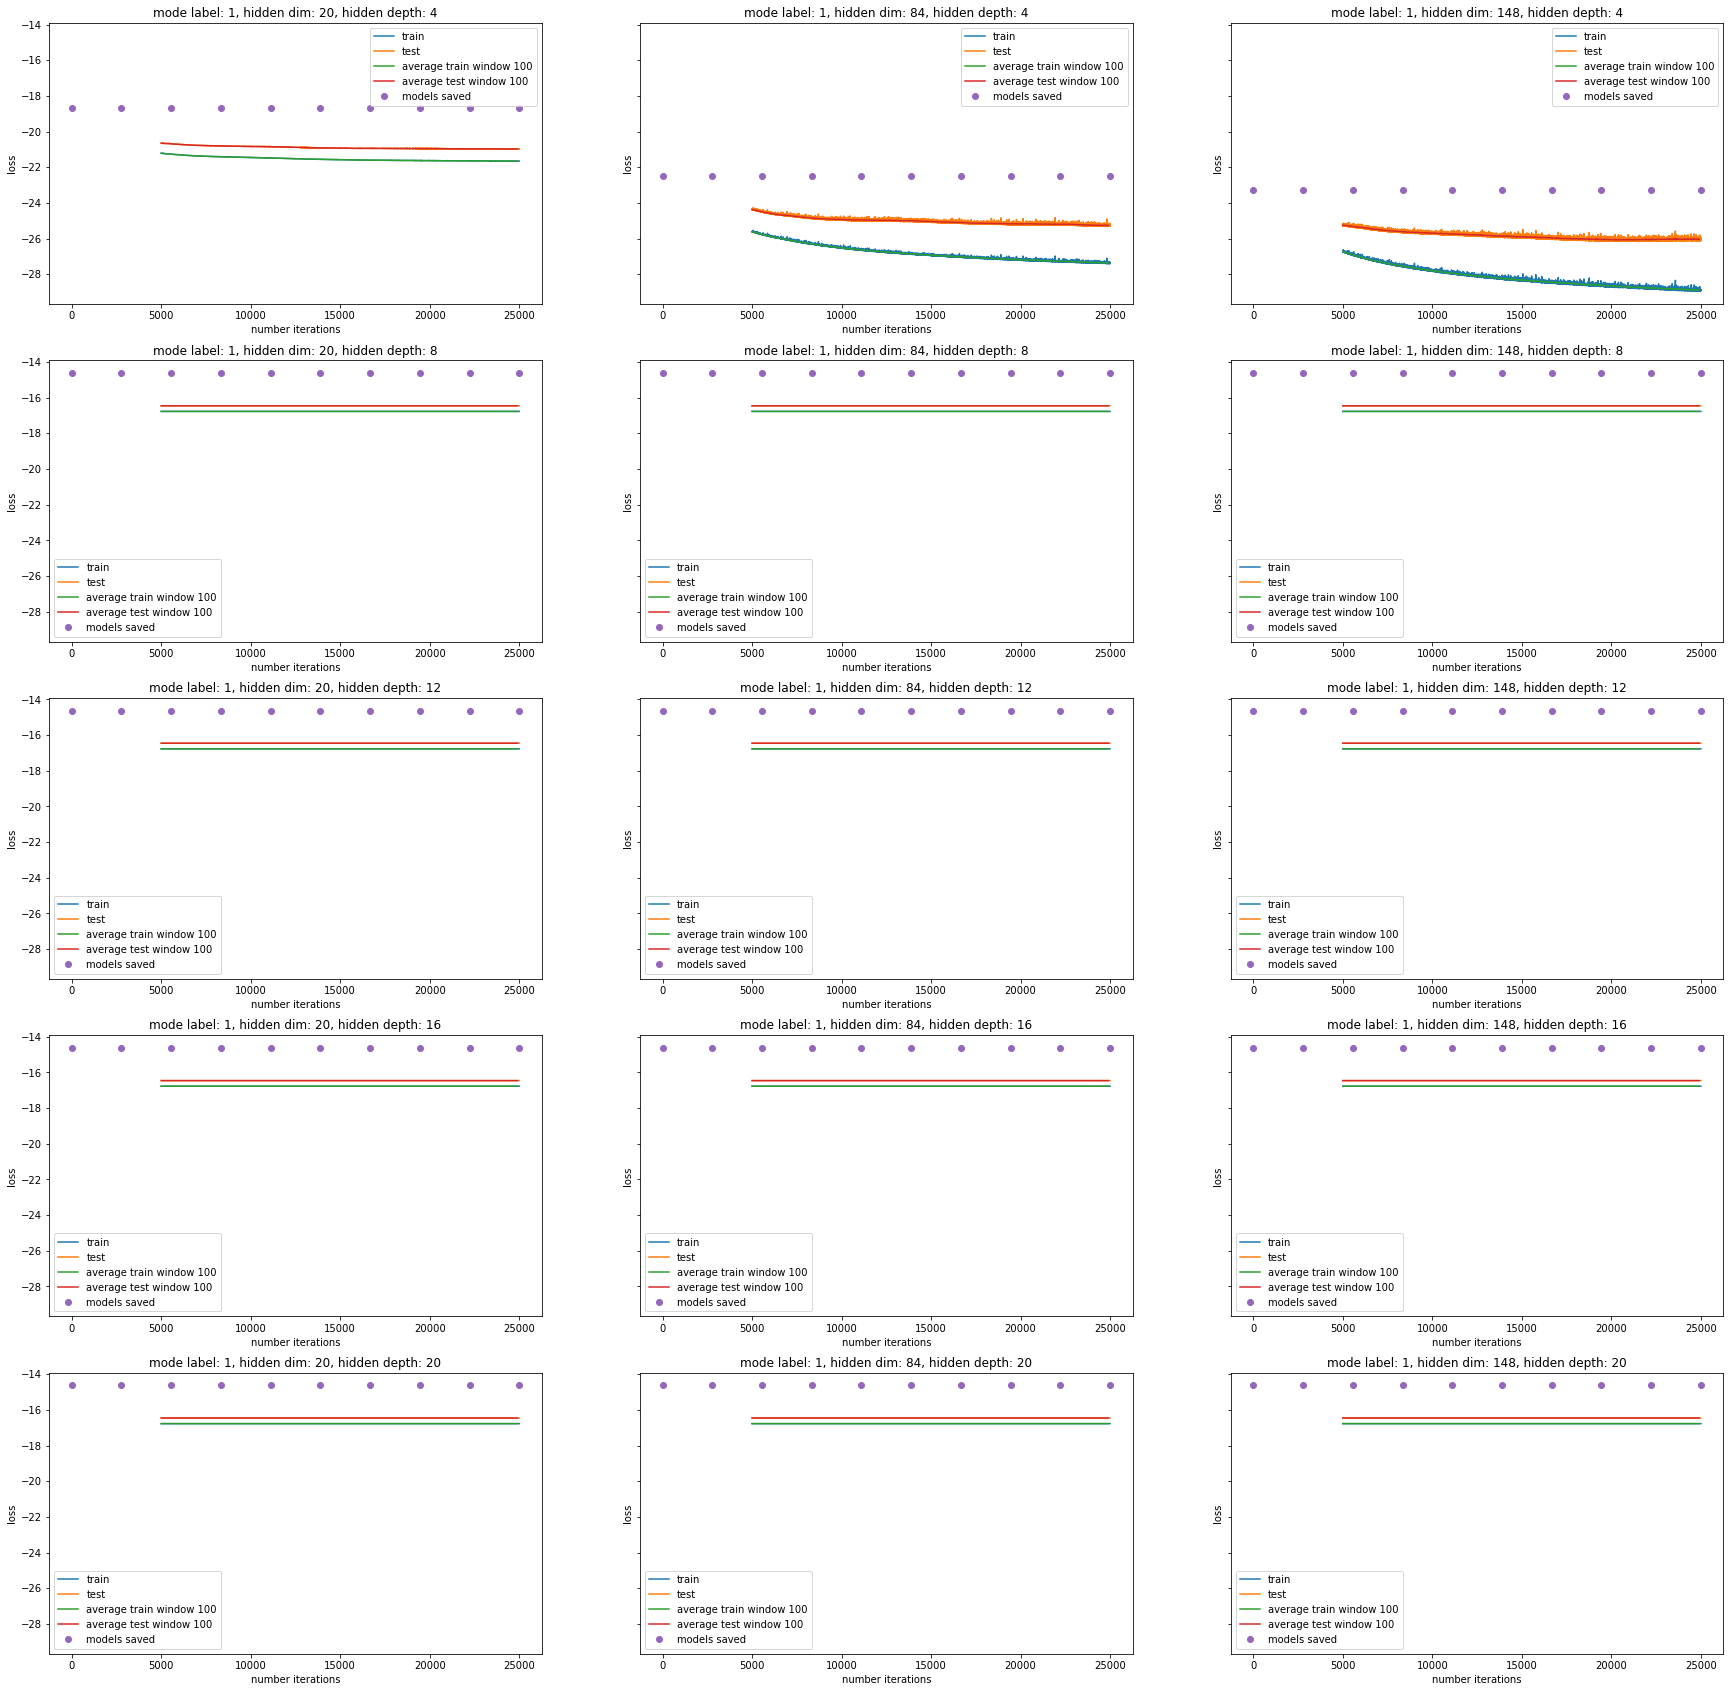

In [79]:
fig, axs = plt.subplots(len(flows_1), len(flows_1[0]), figsize=(30, 30), sharey=True)
for i in range(len(flows_1)):
    for j in range(len(flows_1[i])):
        plot_losses(flows_1[i][j], ax=axs[i][j])

In [80]:
# ========================= TUNING MLPs =========================

In [81]:
ids_mlp_0 = 2148010 + np.arange(0, n_hdp)
ids_mlp_1 = 2148015 + np.arange(0, n_hdp)

In [82]:
mlps_0 = [[load_dic(0, id_mlp_0, i-1, 'mlp') for i in range(start, end, step)] for id_mlp_0 in ids_mlp_0]
mlps_1 = [[load_dic(1, id_mlp_1, i-1, 'mlp') for i in range(start, end, step)] for id_mlp_1 in ids_mlp_1]

In [83]:
#def convergence(arr, delta, compare_step):
#    for i in range(1, len(arr)-compare_step):
#        if abs(arr[i-1]-arr[i]) <= delta and abs(arr[i-1]-arr[i+compare_step]) <= delta:
#            value, steps_needed = arr[i], i
#            return value, steps_needed

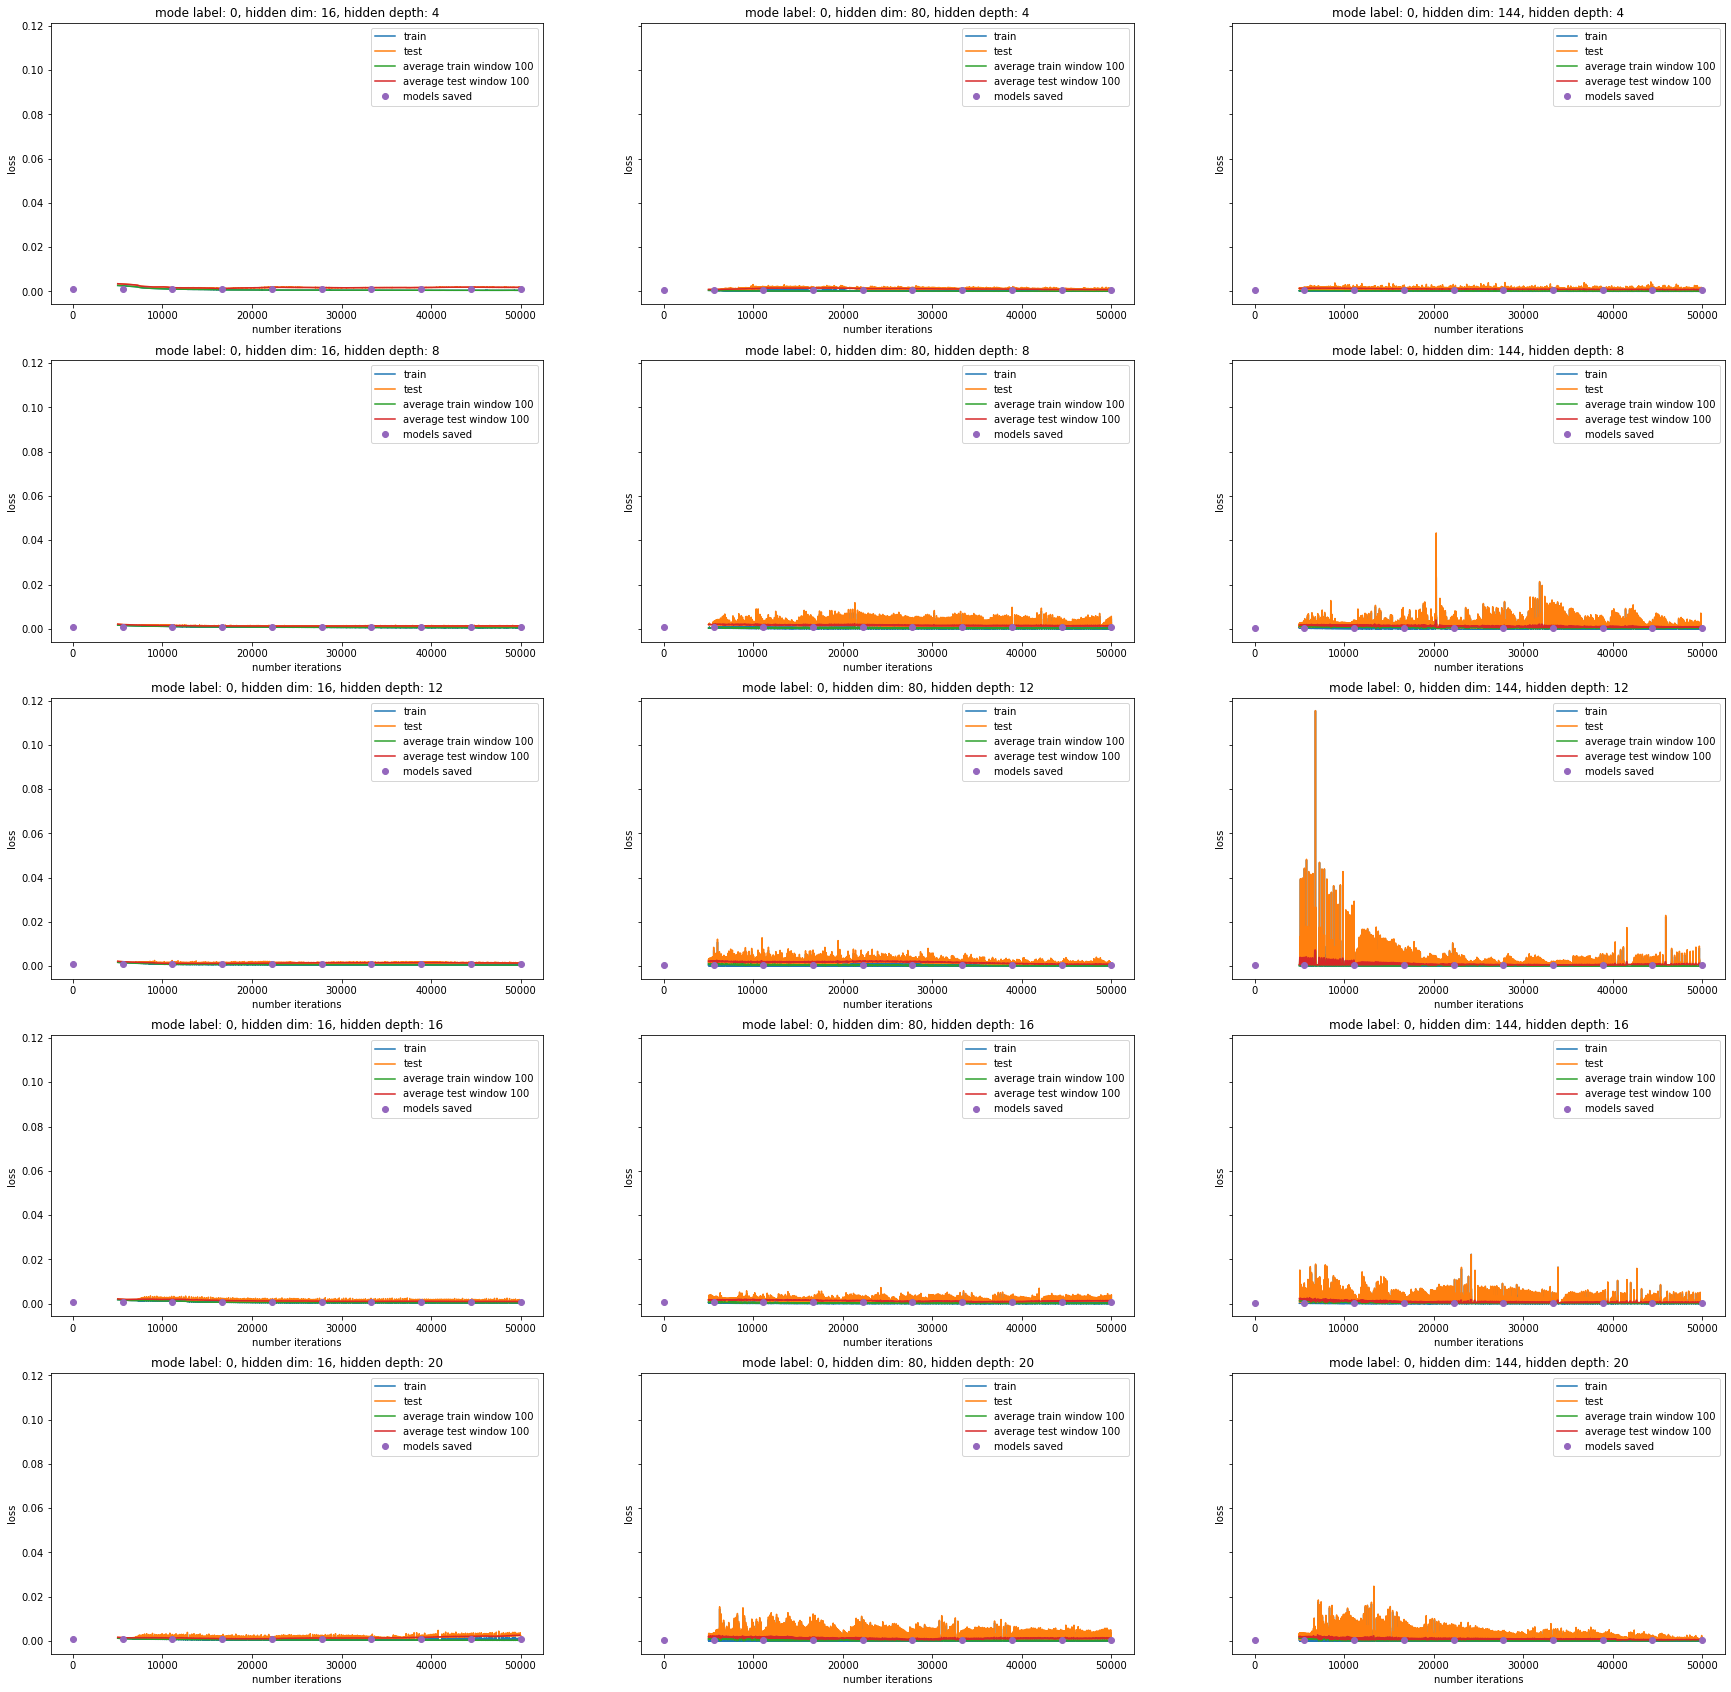

In [84]:
fig, axs = plt.subplots(len(mlps_0), len(mlps_0[0]), figsize=(30, 30), sharey=True)
for i in range(len(mlps_0)):
    for j in range(len(mlps_0[i])):
        plot_losses(mlps_0[i][j], ax=axs[i][j])

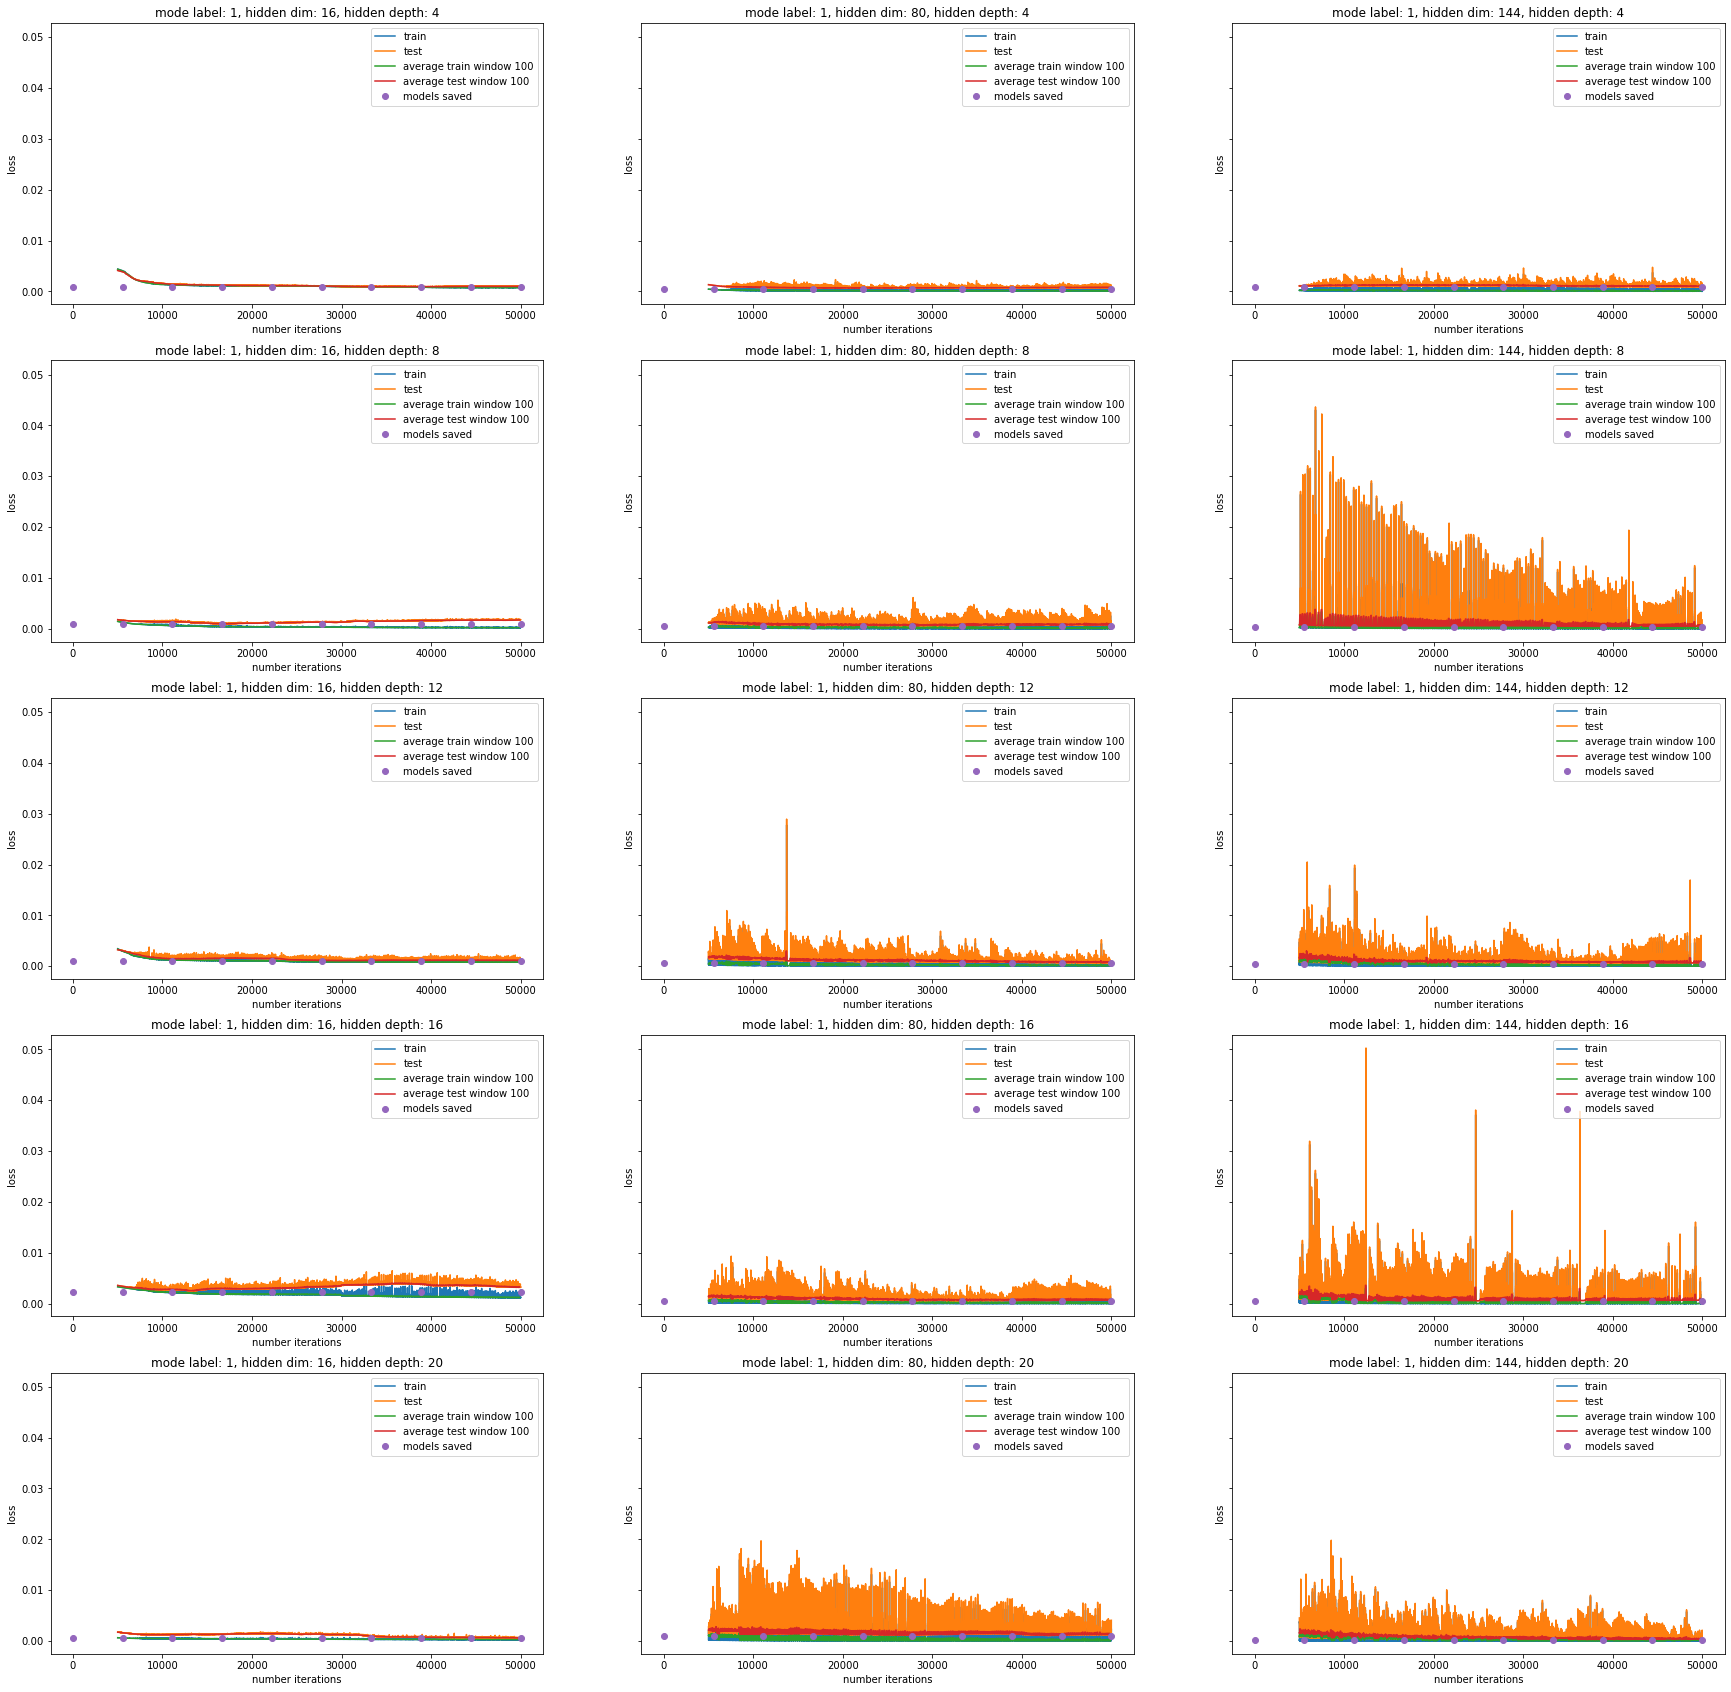

In [85]:
fig, axs = plt.subplots(len(mlps_1), len(mlps_1[0]), figsize=(30, 30), sharey=True)
for i in range(len(mlps_1)):
    for j in range(len(mlps_1[i])):
        plot_losses(mlps_1[i][j], ax=axs[i][j])